<H1>Сводный вариант построения диаграмм</H1>


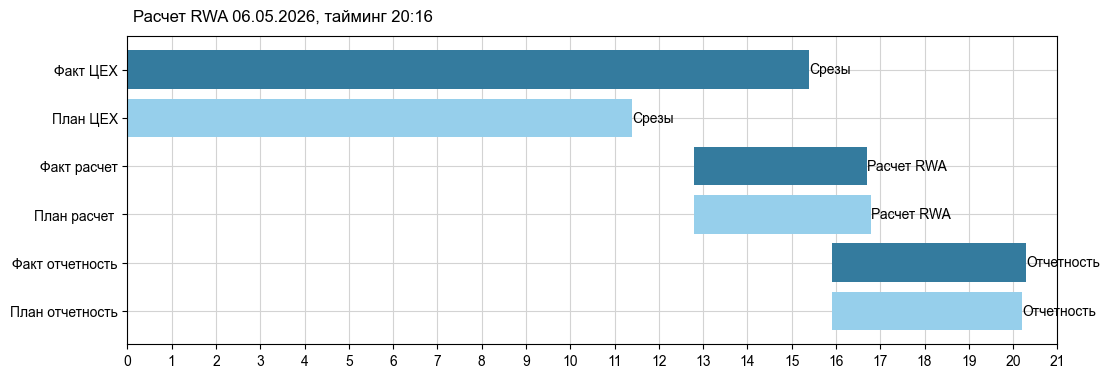

In [1]:
#--------https://uproger.com/3-unikalnye-diagrammy-sozdannye-s-pomoshhyu-matplotlib/

import pandas as pd
import matplotlib.pyplot as plt
#from matplotlib import gridspec
from datetime import datetime

data = pd.read_excel("./rwa07052026свод.xlsx")

# Перевод HH:MM в десятичную дробь
def gethours (tt : datetime):
    return round((tt.hour * 60 + tt.minute)/60, 1)

# Время начала (начало прямоугольника)
start_times = [gethours(h) for h in data['start']]

# Длительность (ширина прямоугольника)
durations = [gethours(fintim)- gethours(startim) for fintim,startim in zip(data['finish'], data['start'])]

# Макс. время (для отметок на оси X)
maxfinish = max(gethours(ff) for ff in (data['finish']))

# Шрифт и размер графика
plt.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(1, figsize=(12,4+int(len(data)/8)))

# Рисование диаграммы
bars = ax.barh (data['system'], durations, left=start_times,color=data['color'], align='center')
#plt.tight_layout()

# Сетка
plt.grid(color='lightgray')
ax.set_axisbelow(True)

# Кастомизация под свои нужды

# выровнять число делений X по макс их всех файлов
plt.xlim(0, 17)
#ax.set_xticks([i for i in range(int(maxfinish) + 2)])


# Отметки на оси X
xticks = [i for i in range(int(maxfinish) + 2)]

# добавить метку на макс времени по таймингам
# xticks.append(maxfinish)

# добавить массив меток
ax.set_xticks(xticks)

# Нарисовать подписи
ax.bar_label(bars, label_type='edge', labels=data['desc'], zorder=2)

# # Нарисовать бенчмарк ОП зеленым пунктиром
# ax.axvline(11.2, color="green", linestyle="--", zorder=3)
# plt.text(11.2, 8.7, "Бенчмарк витрин ЦЕХ", fontsize=9, color='black', ha='right')

# # Нарисовать бенчмарк расчета зеленым пунктиром
# ax.axvline(16.2, color="green", linestyle="--", zorder=2)
# plt.text(16.1, 8.7, "Бенчмарк расчета RWA", fontsize=9, color='black', ha='right')

# # Нарисовать вертикальную черту красным пунктиром
# ax.axvline(maxfinish, color="red", linestyle="--", zorder=1)
# plt.text(maxfinish-.1, -.5, "Факт общего расчета RWA", fontsize=9, color='black', ha='right')


# Написать название диаграммы
total_finish = max(ff for ff in (data['finish']))
plt.text(3.5, -1, f"Расчет RWA 06.05.2026, тайминг {total_finish.hour}:{"{:02d}".format(total_finish.minute)}", fontsize=12, color='black', ha='center')

# plt.text(.1, -.5, "22:13", fontsize=9, color='black', ha='right')

# подпись легенды с линиями бенчмарка
# plt.text(0, 10, "Отметки на диаграмме:", fontsize=12, color='black', ha='left')
# plt.text(4.2, 10, "Бенчмарк", fontsize=12, color='green', ha='left')
# plt.text(8.4, 10, "и полученный", fontsize=12, color='black', ha='right')
# plt.text(8.5, 10, "Факт", fontsize=12, color='red', ha='left')

# вывести ось Y в обратном порядке
plt.gca().invert_yaxis()

